# Producto

## Librerías

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Datos

In [3]:
df_si = pd.read_csv('sell_in_suiza_geo.csv')
df_so = pd.read_csv('limpio/sell_out_suiza_v2.csv')

C:\Users\manue\AppData\Local\Temp\ipykernel_5860\1014752903.py:2: DtypeWarning: Columns (0: FSDCUSTOMERNAME, 1: FSDCUSTOMERFRIENDLYNAME, 2: ROLE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_so = pd.read_csv('limpio/sell_out_suiza_v2.csv')


## Formato

In [4]:
df_si['MONTH_DT'] = pd.to_datetime(df_si['MONTH_DT'])
df_so['MONTHDATE'] = pd.to_datetime(df_so['MONTHDATE'])
df_si['CUSTOMERPOSTALCODE'] = df_si['CUSTOMERPOSTALCODE'].dropna().astype(int)
df_so['POSTALCODE'] = df_so['POSTALCODE'].dropna().astype(int)

print('Sell In:', df_si.shape)
print('Sell Out:', df_so.shape)
print('Listo')

Sell In: (294132, 51)
Sell Out: (704699, 33)
Listo


## Tipo de Producto

##### Posibles tipo de productos disponibles en el Sell-In y en el Sell-Out

In [5]:
cols_producto_si = ['MATL_LEVEL_1_DESC', 'MATL_LEVEL_5_DESC', 
                     'SZ_CLS_DESC', 'UUHP_TIRE_DESC', 
                     'DISTR_CHAN_CD', 'BUSINESS_LOGIC', 'ROF']

print('=== SELL IN - Columnas de producto ===')
for col in cols_producto_si:
    print(f'\n--- {col} ---')
    print(df_si[col].value_counts().head(8))

cols_producto_so = ['BRANDTIER', 'BRAND', 'TIRESEASON', 
                     'ABSEGMENT', 'UUHPSEGMENT', 'RIM', 'ISB2B']

print('\n=== SELL OUT - Columnas de producto ===')
for col in cols_producto_so:
    print(f'\n--- {col} ---')
    print(df_so[col].value_counts().head(8))

=== SELL IN - Columnas de producto ===

--- MATL_LEVEL_1_DESC ---
MATL_LEVEL_1_DESC
Tire    294132
Name: count, dtype: int64

--- MATL_LEVEL_5_DESC ---
MATL_LEVEL_5_DESC
Passenger            209508
4x4                   63511
Light Truck           17878
Ultra Light Truck      1442
Name: count, dtype: int64

--- SZ_CLS_DESC ---
SZ_CLS_DESC
Long Tail     115669
Top Runner     95604
Mainstream     82859
Name: count, dtype: int64

--- UUHP_TIRE_DESC ---
UUHP_TIRE_DESC
uuhp_tire_desc_1    39751
uuhp_tire_desc_2     3096
Name: count, dtype: int64

--- DISTR_CHAN_CD ---
DISTR_CHAN_CD
1    294132
Name: count, dtype: int64

--- BUSINESS_LOGIC ---
BUSINESS_LOGIC
Regular    293119
WSI           960
Fleets         53
Name: count, dtype: int64

--- ROF ---
ROF
N    284920
Y      9212
Name: count, dtype: int64

=== SELL OUT - Columnas de producto ===

--- BRANDTIER ---
BRANDTIER
Premium       488007
Quality       192976
Budget          7981
COMPETITOR       780
Name: count, dtype: int64

--- BRAND -

### Sell-In

##### Distribución por tipo de vehículo en Sell-In

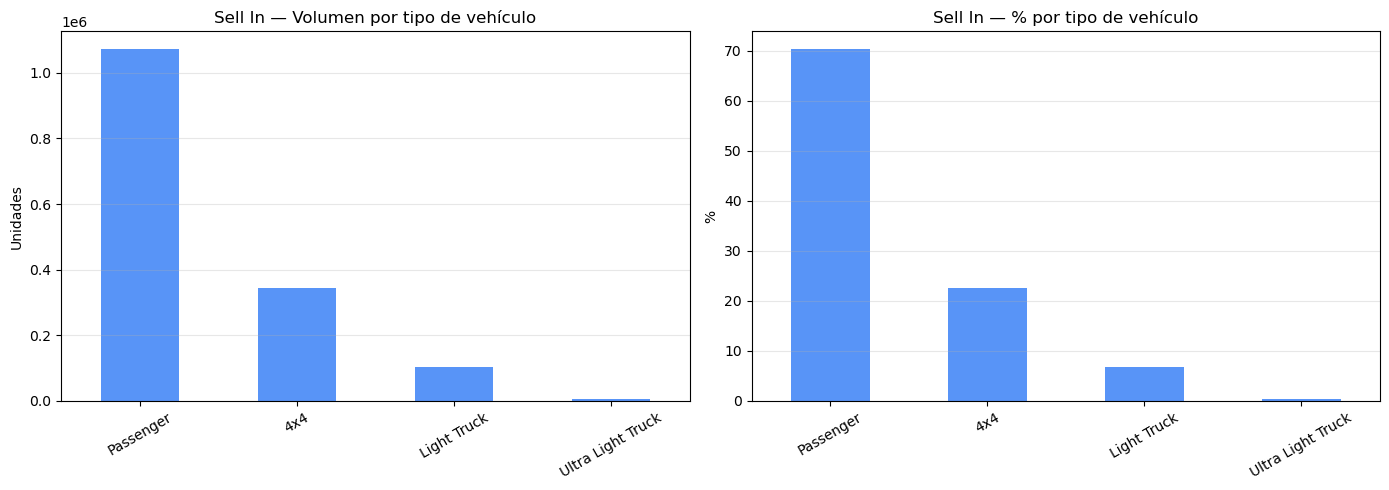

MATL_LEVEL_5_DESC
Passenger            70.3
4x4                  22.5
Light Truck           6.8
Ultra Light Truck     0.3
Name: BILLED_QTY, dtype: float64


In [10]:
si_tipo = df_si.groupby('MATL_LEVEL_5_DESC')['BILLED_QTY'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volumen absoluto
si_tipo.plot(kind='bar', ax=axes[0], color='#3B82F6', alpha=0.85)
axes[0].set_title('Sell In — Volumen por tipo de vehículo')
axes[0].set_ylabel('Unidades')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3, axis='y')

# Porcentaje
si_tipo_pct = si_tipo / si_tipo.sum() * 100
si_tipo_pct.plot(kind='bar', ax=axes[1], color='#3B82F6', alpha=0.85)
axes[1].set_title('Sell In — % por tipo de vehículo')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('producto_tipo_vehiculo.png', dpi=150, bbox_inches='tight')
plt.show()

print(si_tipo_pct.round(1))

##### Tamaño de la rueda en cada tipo de vehículo Sell-In

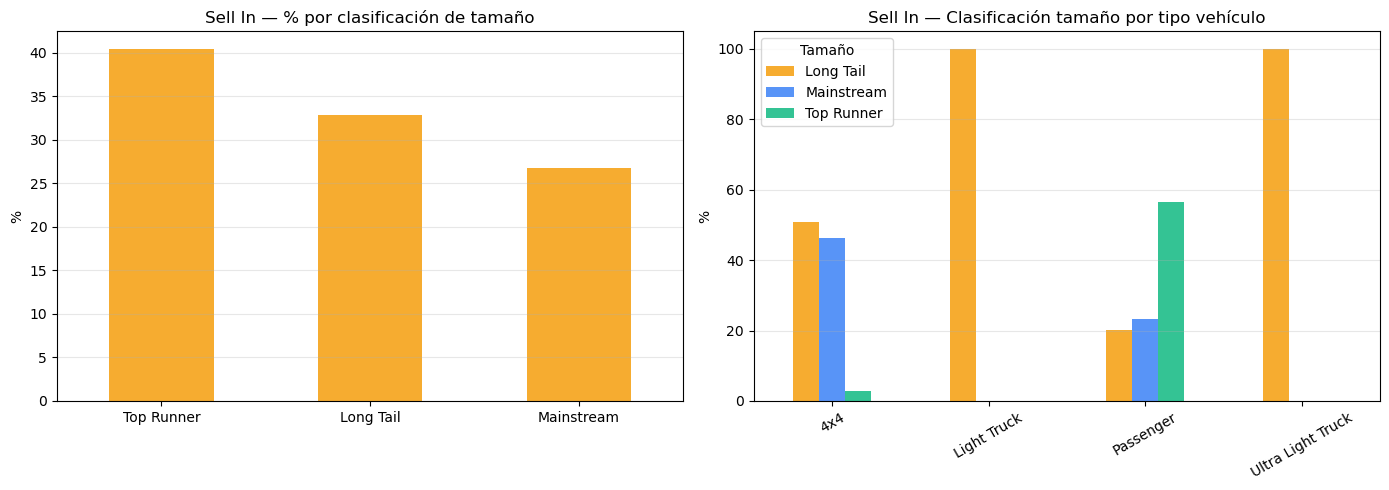

SZ_CLS_DESC
Top Runner    40.4
Long Tail     32.8
Mainstream    26.7
Name: BILLED_QTY, dtype: float64

 SZ_CLS_DESC        Long Tail  Mainstream  Top Runner
MATL_LEVEL_5_DESC                                   
4x4                     50.8        46.4         2.8
Light Truck            100.0         NaN         NaN
Passenger               20.2        23.2        56.6
Ultra Light Truck      100.0         NaN         NaN


In [11]:
si_szc = df_si.groupby('SZ_CLS_DESC')['BILLED_QTY'].sum().sort_values(ascending=False)
si_szc_pct = si_szc / si_szc.sum() * 100

# Cruce tipo vehículo x clasificación tamaño
si_cruce = df_si.groupby(['MATL_LEVEL_5_DESC', 'SZ_CLS_DESC'])['BILLED_QTY'].sum().unstack()
si_cruce_pct = si_cruce.div(si_cruce.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución global
si_szc_pct.plot(kind='bar', ax=axes[0], color='#F59E0B', alpha=0.85)
axes[0].set_title('Sell In — % por clasificación de tamaño')
axes[0].set_ylabel('%')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Cruce
si_cruce_pct.plot(kind='bar', ax=axes[1], color=['#F59E0B', '#3B82F6', '#10B981'],
                  alpha=0.85)
axes[1].set_title('Sell In — Clasificación tamaño por tipo vehículo')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Tamaño')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('producto_clasificacion_tamano.png', dpi=150, bbox_inches='tight')
plt.show()

print(si_szc_pct.round(1))
print('\n', si_cruce_pct.round(1))

##### Evolución de crecimiento del mix de vehículo Sell-In

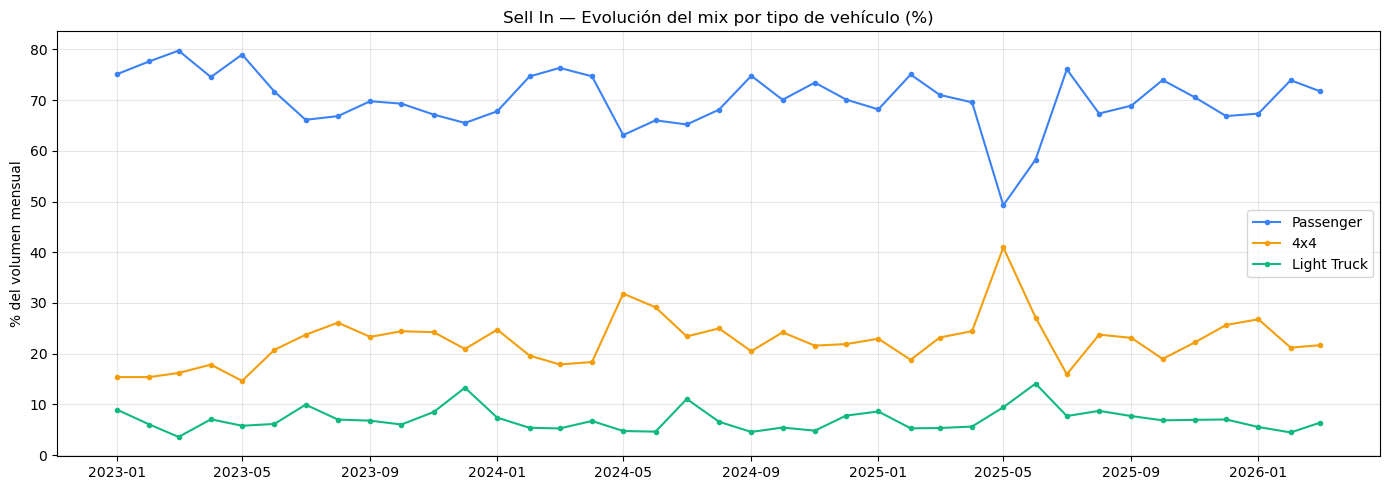

In [12]:
si_mix_tiempo = df_si.groupby(['MONTH_DT', 'MATL_LEVEL_5_DESC'])['BILLED_QTY'].sum().unstack()
si_mix_tiempo_pct = si_mix_tiempo.div(si_mix_tiempo.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))

colores = {'Passenger': '#3B82F6', '4x4': '#F59E0B', 
           'Light Truck': '#10B981', 'Ultra Light Truck': '#8B5CF6'}

for col in ['Passenger', '4x4', 'Light Truck']:
    ax.plot(si_mix_tiempo_pct.index, si_mix_tiempo_pct[col],
            linewidth=1.5, marker='o', markersize=3,
            color=colores[col], label=col)

ax.set_title('Sell In — Evolución del mix por tipo de vehículo (%)')
ax.set_ylabel('% del volumen mensual')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('producto_mix_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

Anomalía de 2025

In [13]:
mayo_2025 = df_si[df_si['MONTH_DT'] == '2025-05-01']

print('Registros mayo 2025:', len(mayo_2025))
print('\nVolumen por tipo:')
print(mayo_2025.groupby('MATL_LEVEL_5_DESC')['BILLED_QTY'].sum())

print('\nTop 5 clientes por volumen 4x4 en mayo 2025:')
print(mayo_2025[mayo_2025['MATL_LEVEL_5_DESC']=='4x4'].groupby(
    'PAYER_CUSTOMER_NAME')['BILLED_QTY'].sum().sort_values(ascending=False).head(5))

Registros mayo 2025: 6359

Volumen por tipo:
MATL_LEVEL_5_DESC
4x4                  13776.0
Light Truck           3169.0
Passenger            16570.0
Ultra Light Truck      118.0
Name: BILLED_QTY, dtype: float64

Top 5 clientes por volumen 4x4 en mayo 2025:
PAYER_CUSTOMER_NAME
Entidad_382    5330.0
Entidad_667    1128.0
Entidad_34      992.0
Empresa_4_A     885.0
Entidad_674     822.0
Name: BILLED_QTY, dtype: float64


### Sell-Out

##### RIM Sell-Out

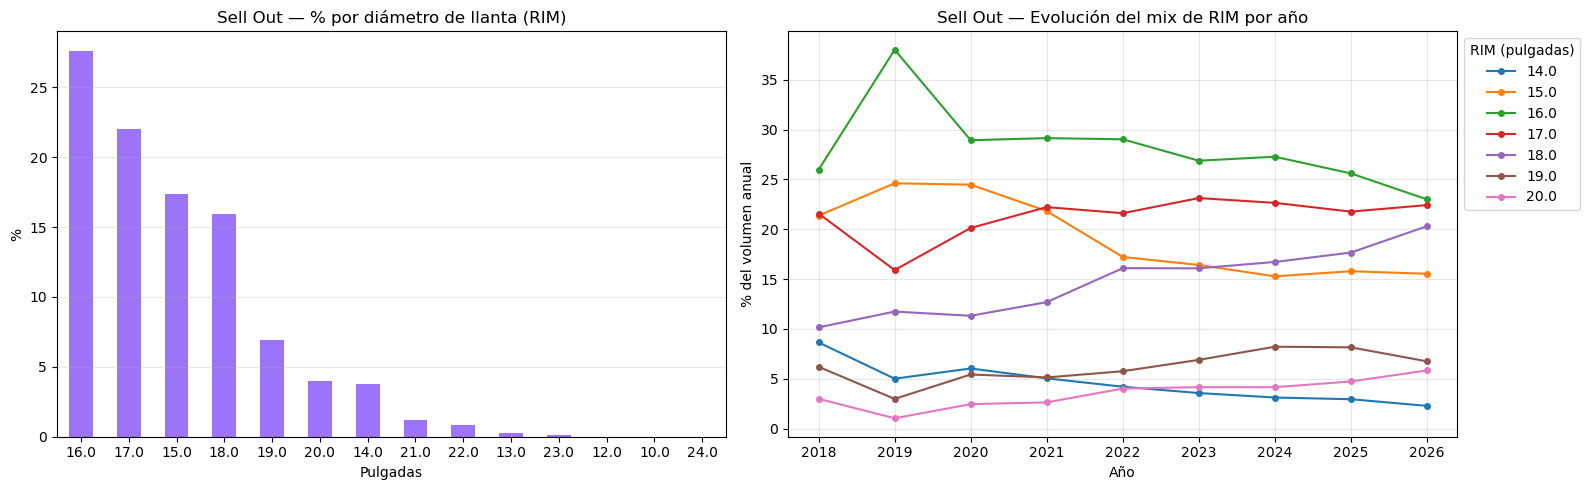

RIM
16.0    27.6
17.0    22.0
15.0    17.3
18.0    15.9
19.0     6.9
20.0     4.0
14.0     3.8
21.0     1.2
22.0     0.8
13.0     0.3
23.0     0.1
12.0     0.0
10.0     0.0
24.0     0.0
Name: TOTALSELLOUTQTTY, dtype: float64


In [14]:
so_rim = df_so.groupby('RIM')['TOTALSELLOUTQTTY'].sum().sort_values(ascending=False)
so_rim_pct = so_rim / so_rim.sum() * 100

# Evolución del RIM a lo largo del tiempo (tendencia hacia llantas más grandes)
so_rim_tiempo = df_so.groupby([df_so['MONTHDATE'].dt.year, 'RIM'])['TOTALSELLOUTQTTY'].sum().unstack()
so_rim_tiempo_pct = so_rim_tiempo.div(so_rim_tiempo.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

so_rim_pct.plot(kind='bar', ax=axes[0], color='#8B5CF6', alpha=0.85)
axes[0].set_title('Sell Out — % por diámetro de llanta (RIM)')
axes[0].set_ylabel('%')
axes[0].set_xlabel('Pulgadas')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

so_rim_tiempo_pct[[14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]].plot(
    ax=axes[1], marker='o', linewidth=1.5, markersize=4)
axes[1].set_title('Sell Out — Evolución del mix de RIM por año')
axes[1].set_ylabel('% del volumen anual')
axes[1].set_xlabel('Año')
axes[1].legend(title='RIM (pulgadas)', bbox_to_anchor=(1, 1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('producto_rim.png', dpi=150, bbox_inches='tight')
plt.show()

print(so_rim_pct.round(1))

Se puede ver una clara tendencia hacia ruedas con un mayor RIM, lo que reafirma la tendencia de más 4x4/SUV en circulación

##### BRANDTIER Sell-Out

In [16]:
so_bt = df_so.groupby('BRANDTIER')['TOTALSELLOUTQTTY'].sum().sort_values(ascending=False)
so_bt_pct = so_bt / so_bt.sum() * 100

print(so_bt_pct.round(1))

BRANDTIER
Premium       72.6
Quality       26.7
Budget         0.6
COMPETITOR     0.1
Name: TOTALSELLOUTQTTY, dtype: float64


Evolución por Cantón

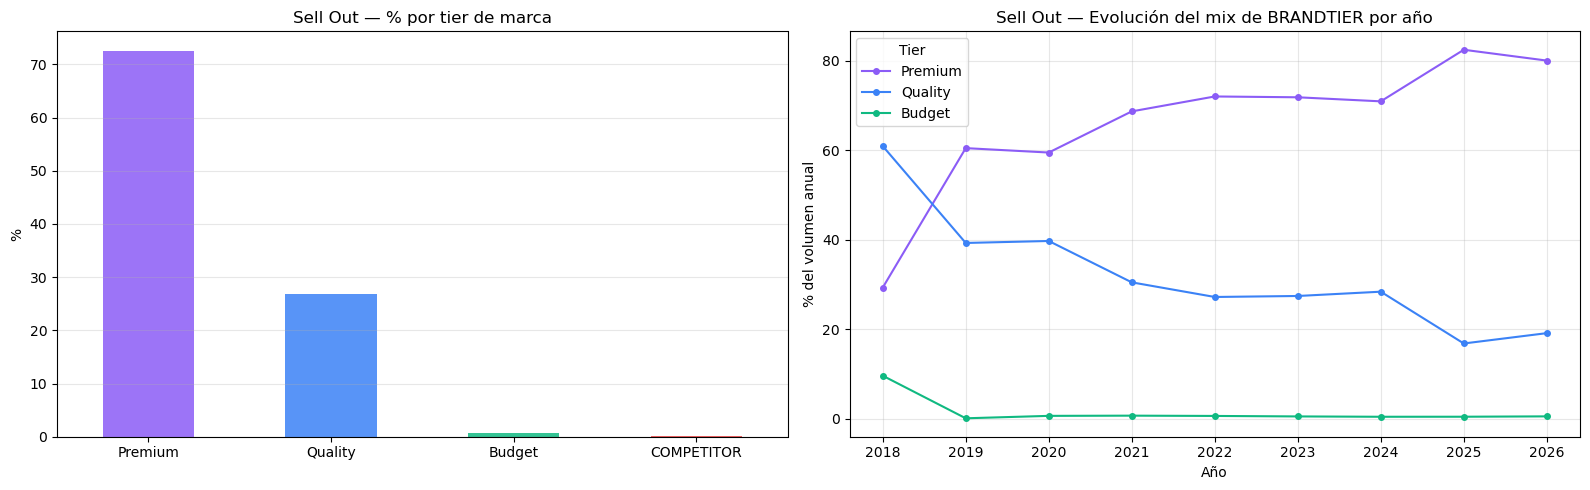

In [17]:
so_bt_tiempo = df_so.groupby([df_so['MONTHDATE'].dt.year, 
                               'BRANDTIER'])['TOTALSELLOUTQTTY'].sum().unstack()
so_bt_tiempo_pct = so_bt_tiempo.div(so_bt_tiempo.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colores_bt = {'Premium': '#8B5CF6', 'Quality': '#3B82F6', 
              'Budget': '#10B981', 'COMPETITOR': '#EF4444'}

so_bt_pct.plot(kind='bar', ax=axes[0], 
               color=[colores_bt[b] for b in so_bt_pct.index],
               alpha=0.85)
axes[0].set_title('Sell Out — % por tier de marca')
axes[0].set_ylabel('%')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

for tier in ['Premium', 'Quality', 'Budget']:
    if tier in so_bt_tiempo_pct.columns:
        axes[1].plot(so_bt_tiempo_pct.index, so_bt_tiempo_pct[tier],
                    marker='o', linewidth=1.5, markersize=4,
                    color=colores_bt[tier], label=tier)

axes[1].set_title('Sell Out — Evolución del mix de BRANDTIER por año')
axes[1].set_ylabel('% del volumen anual')
axes[1].set_xlabel('Año')
axes[1].legend(title='Tier')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('producto_brandtier.png', dpi=150, bbox_inches='tight')
plt.show()

Estacionalidad de Brandtier

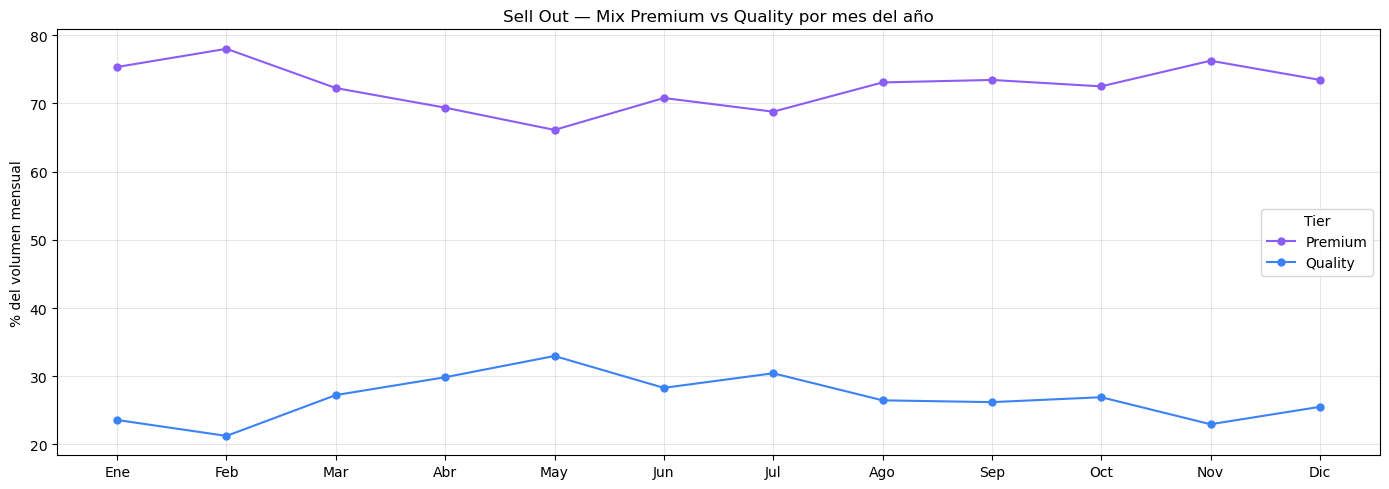

In [18]:
so_bt_mes = df_so.groupby([df_so['MONTHDATE'].dt.month, 
                            'BRANDTIER'])['TOTALSELLOUTQTTY'].sum().unstack()
so_bt_mes_pct = so_bt_mes.div(so_bt_mes.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))

for tier in ['Premium', 'Quality']:
    ax.plot(range(1,13), so_bt_mes_pct[tier],
            marker='o', linewidth=1.5, markersize=5,
            color=colores_bt[tier], label=tier)

ax.set_xticks(range(1,13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_title('Sell Out — Mix Premium vs Quality por mes del año')
ax.set_ylabel('% del volumen mensual')
ax.legend(title='Tier')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('producto_brandtier_estacional.png', dpi=150, bbox_inches='tight')
plt.show()

Los picos de Quality y bajos de Premium coinciden con los inicios de temporadas secas donde las carreteras son menos peligrosas, y los picos de premium y los bajos de quality cuando comiezan temporadas con lluvia y nieve donde son más peligrosas las carreteras y se busca mayor seguridad

##### Estacionalidad por Brandtier y tipo de neumático (Segmento Premium)

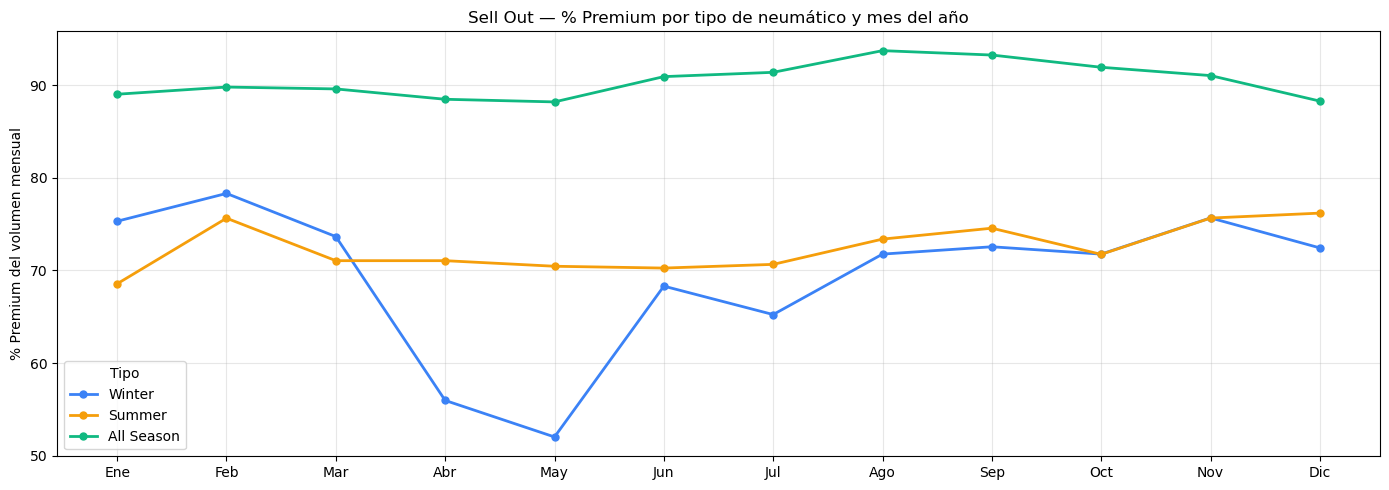

TIRESEASON  All Season  Summer  Winter
MONTHDATE                             
1                 89.0    68.6    75.3
2                 89.8    75.6    78.3
3                 89.6    71.1    73.7
4                 88.5    71.1    56.0
5                 88.2    70.5    52.0
6                 90.9    70.3    68.3
7                 91.4    70.7    65.2
8                 93.7    73.4    71.8
9                 93.3    74.6    72.6
10                91.9    71.7    71.8
11                91.0    75.7    75.7
12                88.3    76.2    72.4


In [19]:
so_bt_tipo_mes = df_so.groupby([
    df_so['MONTHDATE'].dt.month, 
    'TIRESEASON', 
    'BRANDTIER'])['TOTALSELLOUTQTTY'].sum().unstack('BRANDTIER')

so_bt_tipo_mes_pct = so_bt_tipo_mes.div(so_bt_tipo_mes.sum(axis=1), axis=0) * 100

premium_tipo_mes = so_bt_tipo_mes_pct['Premium'].unstack('TIRESEASON')

fig, ax = plt.subplots(figsize=(14, 5))

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
colores_tipo = {'Winter': '#3B82F6', 'Summer': '#F59E0B', 'All Season': '#10B981'}

for tipo in ['Winter', 'Summer', 'All Season']:
    if tipo in premium_tipo_mes.columns:
        ax.plot(range(1,13), premium_tipo_mes[tipo],
                marker='o', linewidth=2, markersize=5,
                color=colores_tipo[tipo], label=tipo)

ax.set_xticks(range(1,13))
ax.set_xticklabels(meses)
ax.set_title('Sell Out — % Premium por tipo de neumático y mes del año')
ax.set_ylabel('% Premium del volumen mensual')
ax.legend(title='Tipo')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('producto_premium_tipo_mes.png', dpi=150, bbox_inches='tight')
plt.show()

print(premium_tipo_mes.round(1))

##### Evolución de RIM por Brandtier

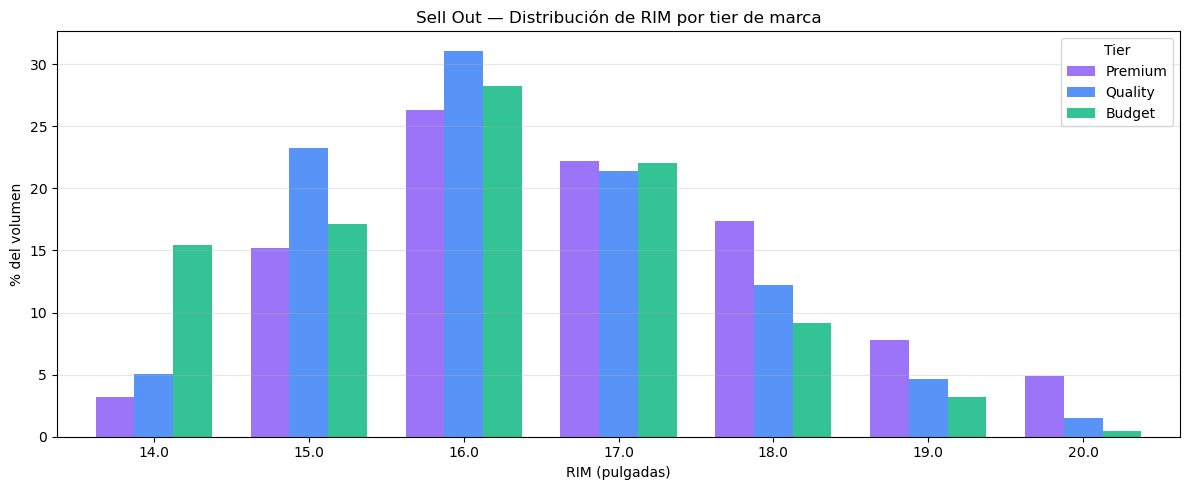

RIM        14.0  15.0  16.0  17.0  18.0  19.0  20.0
BRANDTIER                                          
Premium     3.2  15.2  26.3  22.2  17.3   7.8   4.9
Quality     5.0  23.2  31.1  21.4  12.2   4.6   1.5
Budget     15.4  17.2  28.2  22.0   9.1   3.2   0.4


In [20]:
so_rim_bt = df_so.groupby(['BRANDTIER', 'RIM'])['TOTALSELLOUTQTTY'].sum().unstack('RIM')
so_rim_bt_pct = so_rim_bt.div(so_rim_bt.sum(axis=1), axis=0) * 100

# Filtrar RIMs relevantes y BRANDTIERs principales
rims_relevantes = [14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]
tiers_principales = ['Premium', 'Quality', 'Budget']

so_rim_bt_pct = so_rim_bt_pct[rims_relevantes].loc[tiers_principales]

fig, ax = plt.subplots(figsize=(12, 5))

so_rim_bt_pct.T.plot(kind='bar', ax=ax, 
                      color=['#8B5CF6', '#3B82F6', '#10B981'],
                      alpha=0.85, width=0.75)

ax.set_title('Sell Out — Distribución de RIM por tier de marca')
ax.set_xlabel('RIM (pulgadas)')
ax.set_ylabel('% del volumen')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Tier')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('producto_rim_brandtier.png', dpi=150, bbox_inches='tight')
plt.show()

print(so_rim_bt_pct.round(1))

Los de RIM 14 predomina budget, esto puede ser a que son coches más pequeños, urbanos, que no necesitan de ruedas tan especializadas. Los de RIM 15 y 16 Predomina Quality al ser coches de pasajeros y de uso diario donde incluye viajes de distancia media. Los de RIM 17 pertenecen a SUVs donde los tres tier están muy parejos debido a la variedad de gamas y por ende los presupuestos de los usuarios al ser ruedas más grandes y caras. A partir de RIM 18 pertenece a un parking de lujo donde el premium predomina.

##### Evolución del ROF (segmento de lujo)

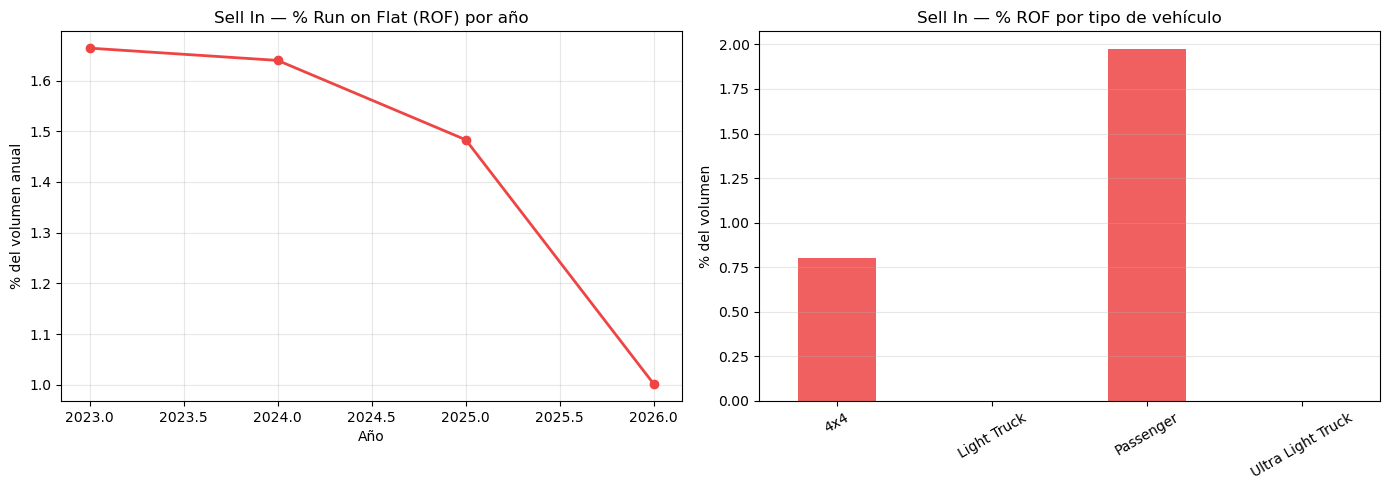

ROF por año:
MONTH_DT
2023    1.66
2024    1.64
2025    1.48
2026    1.00
Name: Y, dtype: float64

ROF por tipo vehículo:
MATL_LEVEL_5_DESC
4x4                  0.80
Light Truck           NaN
Passenger            1.97
Ultra Light Truck     NaN
Name: Y, dtype: float64


In [21]:
si_rof = df_si.groupby([df_si['MONTH_DT'].dt.year, 'ROF'])['BILLED_QTY'].sum().unstack()
si_rof_pct = si_rof.div(si_rof.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

si_rof_pct['Y'].plot(ax=axes[0], marker='o', linewidth=2, 
                      markersize=6, color='#EF4444')
axes[0].set_title('Sell In — % Run on Flat (ROF) por año')
axes[0].set_ylabel('% del volumen anual')
axes[0].set_xlabel('Año')
axes[0].grid(True, alpha=0.3)

si_rof_tipo = df_si.groupby(['MATL_LEVEL_5_DESC', 'ROF'])['BILLED_QTY'].sum().unstack()
si_rof_tipo_pct = si_rof_tipo.div(si_rof_tipo.sum(axis=1), axis=0) * 100

si_rof_tipo_pct['Y'].plot(kind='bar', ax=axes[1], 
                           color='#EF4444', alpha=0.85)
axes[1].set_title('Sell In — % ROF por tipo de vehículo')
axes[1].set_ylabel('% del volumen')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('producto_rof.png', dpi=150, bbox_inches='tight')
plt.show()

print('ROF por año:')
print(si_rof_pct['Y'].round(2))
print('\nROF por tipo vehículo:')
print(si_rof_tipo_pct['Y'].round(2))